In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pybiomart import Dataset
import random
import dansy

In [2]:
# First need to import and create an ID conversion dataframe
bm_dataset = Dataset(host = 'http://useast.ensembl.org', name='hsapiens_gene_ensembl',)
gene_ID_conv = bm_dataset.query(attributes=['ensembl_gene_id','external_gene_name','uniprotswissprot'])

# Importing a small reference file
ref = pd.read_csv('DANSy_test_ref.csv')
full_ref,_ = dansy.import_proteome_files(reference_file_suffix='Jan7_2025.csv', ref_file_dir='../')


In [3]:
# Now creating only a small version of the ID conversion dataframe
small_id_conv = gene_ID_conv[gene_ID_conv['UniProtKB/Swiss-Prot ID'].isin(ref['UniProt ID'])]

In [99]:
# Building the dedansy object
dataset = pd.read_csv('Shimpi_Tan_RNA_seq_Results.csv')
small_dataset = dataset[dataset['ensembl_gene_id'].isin(small_id_conv['Gene stable ID'])]

small_dedansy = dansy.DEdansy(dataset=dataset, id_conv=gene_ID_conv, 
                              data_ids='ensembl_gene_id',
                              uniprot_ref=full_ref)
large_cc = max(nx.connected_components(small_dedansy.G), key = len)
base_interpro = small_dedansy.interpro2uniprot
ref_G = small_dedansy.G

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.
Building the reference network information.


In [135]:
# Getting the proteins within the largest connected component
random.seed(123)
prots2keep = set()

# Restricting protein choice to be neighbors of the SH2 or Kinase domains and 20 randomly chosen nodes from the largest connected component
nodes_2_check = list(nx.neighbors(ref_G, 'IPR000980')) + list(nx.neighbors(ref_G, 'IPR000719')) + random.sample(sorted(large_cc), k =30) +['IPR000980','IPR000719']

for node in nodes_2_check:
    
    x = base_interpro[node]
    prots2keep.update(x)

# Now getting 20 randomly from the largest cc
small_prots = random.sample(sorted(prots2keep), k=20)

In [136]:
small_ref = full_ref[full_ref['UniProt ID'].isin(small_prots)]
small_id_conv = gene_ID_conv[gene_ID_conv['UniProtKB/Swiss-Prot ID'].isin(small_prots)]
small_dataset = dataset[dataset['ensembl_gene_id'].isin(small_id_conv['Gene stable ID'])]

In [137]:
small_dedansy = dansy.DEdansy(dataset=small_dataset, id_conv=small_id_conv, 
                              data_ids='ensembl_gene_id',
                              uniprot_ref=small_ref)

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.
Building the reference network information.


In [138]:
x = small_dedansy.dataset
x = x.filter(['ensembl_gene_id','log2FoldChange_HAS2','padj_HAS2'])
x.rename({'log2FoldChange_HAS2':'log2_FoldChange','padj_HAS2':'padj'},axis=1, inplace=True)
x.to_csv('Small_test_deDANSy_dataset.csv',index=False)

In [160]:
# Creating a toy dataset that can be used for testing if the package is working properly. This will distribute logfoldchanges across the gene and p-values
new_fcs = np.random.normal(0,5,20)
new_alphas = np.random.lognormal(size=20)

In [161]:
x['log2_FoldChange'] = new_fcs
x['padj'] = 10**(-1*new_alphas)

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.
Building the reference network information.


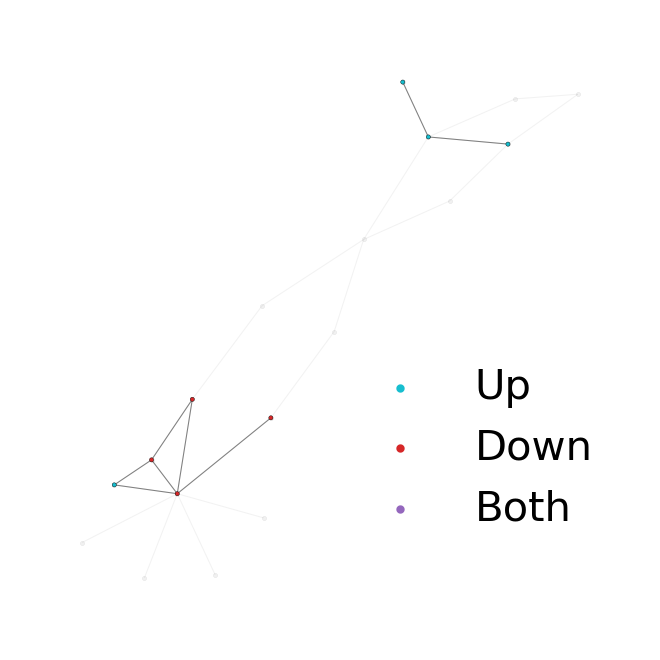

In [162]:
small_dedansy = dansy.DEdansy(dataset=x, id_conv=small_id_conv, 
                              data_ids='ensembl_gene_id',
                              uniprot_ref=small_ref)
small_dedansy.create_contrast_metadata(comparisons=['loose','restrictive'],
                                        fc_cols=['log2_FoldChange', 'log2_FoldChange'],
                                       pval_cols=['padj','padj'],
                                       fcs=[0.5,1],
                                       alphas=[0.05,0.01])
small_dedansy.calc_DEG_ngrams('loose')
pos = nx.spring_layout(small_dedansy.G)
small_dedansy.plot_DEG_ns(pos)

Will be overwriting existing DEG data.


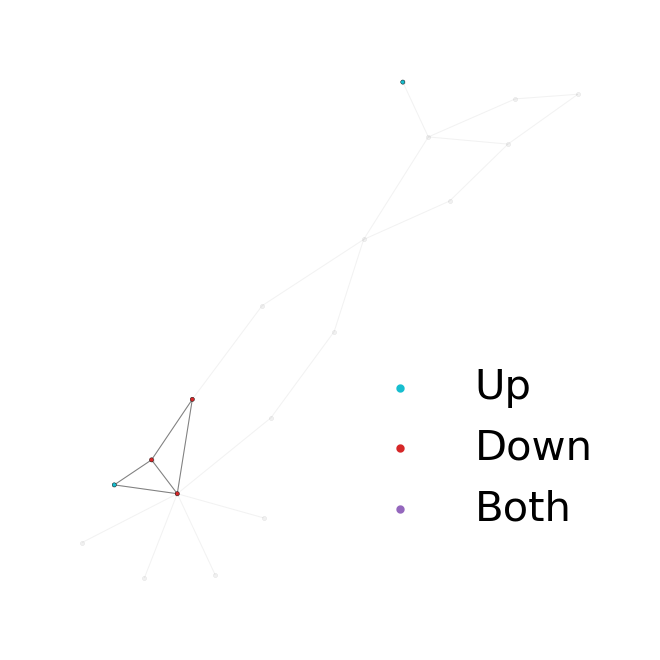

In [163]:
small_dedansy.calc_DEG_ngrams('restrictive')
small_dedansy.plot_DEG_ns(pos)

In [164]:
small_dedansy.calculate_scores(comps = ['loose', 'restrictive'],num_ss_trials=5, fpr_trials=1,min_pval=-4, processes=1,overwrite=True)

2025-08-11 12:17:24:.....Starting deDANSy scoring analysis with random seed: 1754929044
2025-08-11 12:17:24:.....Done with enrichment-based pruning for loose
2025-08-11 12:17:24:.....Done with enrichment-based pruning for restrictive
2025-08-11 12:17:24:.....Starting the false positive rate procedure.
2025-08-11 12:17:24:.....Finished FPR procedure for loose.
2025-08-11 12:17:24:.....Finished FPR procedure for restrictive.
2025-08-11 12:17:24:.....Preparing the FPR results for export


In [165]:
small_dedansy.scores

,Comparison,Separation_Score,Separation_Category,Separation_p,Separation_FPR,Distinction_Score,Distinction_Category,Distinction_p,Distinction_FPR
Comparison,,,,,,,,,
loose,loose,0.512952,More,0.833534,1.0,0.755102,Unstable/Overlapping,0.387094,1.0
restrictive,restrictive,0.817012,More,NaN,0.0,0.929458,Unstable/Overlapping,NaN,0.0


In [166]:
x.to_csv('Small_test_deDANSy_dataset.csv',index=False)

In [170]:
small_ref.to_csv('Testing_Reference_File.csv', index=False)


In [172]:
small_id_conv.to_csv('Testing_ID_Conversion.csv', index=False)

In [177]:
small_dedansy.calc_DEG_ngrams('restrictive')
ns = small_dedansy.DEG_network_sep()

Will be overwriting existing DEG data.


In [180]:
if np.isnan(ns)==False:
    print('Huh?')

Huh?


In [186]:
small_dedansy.calculate_ngram_enrichment('loose',fpr_trials=100)

Will be overwriting existing DEG data.


In [191]:
small_dedansy.ngram_results['loose']

,variable,p,ngram,FPR,-log10(p),FPR <= 0.05
0,Up,0.140351,IPR000980,0.000000,0.852785,True
1,Up,0.284211,IPR015022|IPR000719|IPR000961|IPR001478,0.054054,0.546360,False
2,Up,0.284211,IPR000980|IPR001496,0.043478,0.546360,True
3,Up,0.150000,IPR002219|IPR003595|IPR014020|IPR000980|IPR006020,0.000000,0.823909,True
12,Down,0.300000,IPR001452|IPR000719,0.000000,0.522879,True
13,Down,0.129128,IPR000719,0.000000,0.888980,True
14,Down,0.342621,IPR000719|IPR000961,0.176471,0.465186,False
15,Down,0.300000,IPR000719|IPR000961|IPR011072|IPR015008|IPR001849,0.000000,0.522879,True


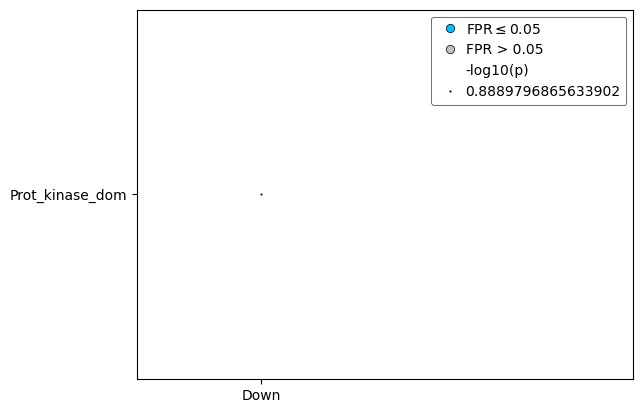

In [194]:
small_dedansy.plot_ngram_enrichment('loose',p=0.99)